In [1]:
#Import packages 

import numpy as np 
import geopandas as gpd 
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pandas as pd 
from shapely.geometry import shape 
import json 
from shapely import wkt 
from shapely.geometry import Point
from shapely.geometry import box
from math import cos, radians
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable
import seaborn as sns 
import matplotlib
from statsmodels.tsa.seasonal import seasonal_decompose
# import contextily as ctx
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans

import glob
import os
import csv
import ast
import matplotlib.patheffects as path_effects
from matplotlib.ticker import PercentFormatter

# from libpysal import weights

from matplotlib.colors import (
    ListedColormap,
    BoundaryNorm,
    LinearSegmentedColormap,
    TwoSlopeNorm
)

from pathlib import Path

In [2]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)

### Read in source files 

In [3]:
# study area gdfs 
new_ea = gpd.read_file(DATA_DIR / 'miscellaneous/new_ea.json')
new_data_study_area = gpd.read_file(DATA_DIR / 'miscellaneous/new_data_study_area.json')

# PQR sites 
new_sites = gpd.read_file(DATA_DIR / 'miscellaneous/new_sites.json')

# shapefile (all EAs)
filt_all_eas_dem_df = gpd.read_file(DATA_DIR / 'miscellaneous/filt_all_eas_dem_df.json')

### Mapping of EAs and PQR sites 

In [4]:
ea_copy_pqr = new_ea.copy()
ea_copy_pqr = ea_copy_pqr[['ea_code9ch', 'geometry']]
merged_sites_pqr = gpd.sjoin(new_sites, ea_copy_pqr, how = 'inner', predicate = 'intersects')

merged_sites_pqr = merged_sites_pqr[['space_grouping', 'geometry', 'ea_code9ch']].reset_index(drop=True)

grouped_sites_df = merged_sites_pqr.groupby('ea_code9ch').agg({
    'space_grouping': lambda x: list(set(x)),  
})

grouped_sites_df = grouped_sites_df.rename(columns = {'space_grouping':'site_id'})

### 2021 Census Districts 

In [5]:
# read districts shapefile for plotting 
dist_2021 = gpd.read_file(DATA_DIR / 'miscellaneous/district_2021_census.geojson')

In [6]:
### Filter out Study Area Districts 

dist_2021 = gpd.sjoin(
    dist_2021, merged_sites_pqr.to_crs('EPSG:4326'), 
    how="inner", 
    predicate='contains' 
).reset_index(drop=True).drop(columns=['index_right'])

dist_2021 = dist_2021.drop_duplicates(['Name']).reset_index(drop=True)

# reproject to local CRS 
dist_2021_transformed = dist_2021.to_crs(merged_sites_pqr.crs)

district_gdf = dist_2021_transformed.copy()

### Revised EA shapefile  

In [7]:
filt_all_eas_dem_df_filt = gpd.sjoin(
    filt_all_eas_dem_df, dist_2021_transformed.drop(columns = ['ea_code9ch']), 
    how="inner", 
    predicate='intersects' 
).reset_index(drop=True)

## exclude additional EAs around the edges for basemap plotting 
additional_eas_to_exclude = [31400149, 31400142, 31400139, 31400134, 31400133, 30801173, 30801139, 30801138, 30801136, 30801063, 30801062, 30100656, 30100652, 30200407, 30200368, 30801041, 30801001, 30100689, 30200426]

filt_all_eas_dem_df_filt = filt_all_eas_dem_df_filt[
    ~filt_all_eas_dem_df_filt['ea_code9ch'].isin(additional_eas_to_exclude)
]

### EAs n Sites  (6km) 

In [8]:
merged_eas_sites = pd.read_csv(DATA_DIR / 'miscellaneous/ea_site_list_6km_buffer.csv')
merged_eas_sites = merged_eas_sites[['ea_code9ch', 'Intersecting_Sites']]

# Convert the string representation of lists to actual lists
merged_eas_sites['Intersecting_Sites'] = merged_eas_sites['Intersecting_Sites'].apply(ast.literal_eval)

### Read EAs and CESI level `rev_1`

In [9]:
eas_n_cesi_level = pd.read_csv(DATA_DIR / 'miscellaneous/eas_cesi_level_214_eas_rev1.csv').drop(columns = ['Unnamed: 0'])

### Merged sites & (214 EAs) 

In [10]:
merged_eas_sites = merged_eas_sites.merge(eas_n_cesi_level, on = 'ea_code9ch').reset_index(drop=True)

In [11]:
# merged_eas_sites

### Explode the site_ids 

In [12]:
merged_eas_sites_exploded = (
    merged_eas_sites
    .explode('Intersecting_Sites', ignore_index=True)
    .rename(columns={'Intersecting_Sites': 'site_id'})
)

merged_eas_sites_exploded['site_id'] = (merged_eas_sites_exploded['site_id'].astype('Int64'))

merged_eas_sites_exploded.head()

,ea_code9ch,site_id,cesi_level
0,30200002,456,Low
1,30200012,430,Low
2,30200013,363,Low
3,30200014,301,Low
4,30200015,104,Low


### filter & get site geometries from main `sample df` 

In [13]:
df = pd.read_csv(DATA_DIR / 'miscellaneous/2022-05-01.csv')

df = df[['time', 'respondent_id', 'site_latitude', 'site_longitude', 'voltage', 'frequency', 'site_id']]

In [14]:
site_coords = (
    df.groupby('site_id')[['site_latitude', 'site_longitude']]
      .first()
      .reset_index()
)

merged_df = merged_eas_sites_exploded.merge(
    site_coords,
    on='site_id',
    how='left'
)

In [15]:
merged_df.head()

,ea_code9ch,site_id,cesi_level,site_latitude,site_longitude
0,30200002,456,Low,5.633024,-0.300601
1,30200012,430,Low,5.638675,-0.300250
2,30200013,363,Low,5.640099,-0.291457
3,30200014,301,Low,5.636135,-0.286370
4,30200015,104,Low,5.644859,-0.290894


In [16]:
merged_df[merged_df['ea_code9ch'] == 30200263]

,ea_code9ch,site_id,cesi_level,site_latitude,site_longitude
34,30200263,351,Low,5.666025,-0.297281
35,30200263,231,Low,NaN,NaN


### read in 1- & 3-day overlap summary df 

In [17]:
ea_1_3_day_risk_flags = pd.read_csv(DATA_DIR / 'miscellaneous/ea_1_3_day_risk_flags.csv').drop(columns = ['Unnamed: 0'])

In [18]:
ea_1_3_day_risk_flags.head()

,ea_code9ch,event,one_day_risk,three_day_risk,both
0,30200016,L,1,0,0
1,30200126,L,0,1,0
2,30200184,L,0,1,0
3,30200198,L,1,0,0
4,30200204,L,0,1,0


### Merge with the EA & sites df 

In [19]:
merged_risk_df = (
    merged_df
    .merge(
        ea_1_3_day_risk_flags,
        on='ea_code9ch',
        how='left',
        validate='many_to_many'
    )
)

risk_cols = ['one_day_risk', 'three_day_risk', 'both']

merged_risk_df[risk_cols] = (
    merged_risk_df[risk_cols]
    .fillna(0)
    .astype(int)
)

In [20]:
merged_risk_df

,ea_code9ch,site_id,cesi_level,site_latitude,site_longitude,event,one_day_risk,three_day_risk,both
0,30200002,456,Low,5.633024,-0.300601,NaN,0,0,0
1,30200012,430,Low,5.638675,-0.300250,NaN,0,0,0
2,30200013,363,Low,5.640099,-0.291457,NaN,0,0,0
3,30200014,301,Low,5.636135,-0.286370,P,0,1,0
4,30200015,104,Low,5.644859,-0.290894,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...
256,31300310,117,Low,5.689682,-0.186315,W,1,0,0
257,31300328,296,Low,5.711324,-0.185577,NaN,0,0,0
258,31300407,445,Low,5.711772,-0.188362,NaN,0,0,0
259,31300449,228,Low,5.659560,-0.167445,NaN,0,0,0


### convert to gdf 

In [21]:
# Convert dataframe to GeoDataFrame
sites_gdf = gpd.GeoDataFrame(
    merged_risk_df,
    geometry=gpd.points_from_xy(
        merged_risk_df['site_longitude'],
        merged_risk_df['site_latitude']
    ),
    crs='EPSG:4326'   # lat/lon CRS
)

# Convert to UTM Zone 30N
sites_gdf = sites_gdf.to_crs(epsg=32630)

In [22]:
sites_gdf = sites_gdf[sites_gdf['event']!='PL'].reset_index(drop=True)

In [23]:
sites_gdf

,ea_code9ch,site_id,cesi_level,site_latitude,site_longitude,event,one_day_risk,three_day_risk,both,geometry
0,30200002,456,Low,5.633024,-0.300601,NaN,0,0,0,POINT (799043.882 623330.318)
1,30200012,430,Low,5.638675,-0.300250,NaN,0,0,0,POINT (799079.904 623955.928)
2,30200013,363,Low,5.640099,-0.291457,NaN,0,0,0,POINT (800054 624118)
3,30200014,301,Low,5.636135,-0.286370,P,0,1,0,POINT (800620 623682)
4,30200015,104,Low,5.644859,-0.290894,NaN,0,0,0,POINT (800114 624645)
...,...,...,...,...,...,...,...,...,...,...
251,31300310,117,Low,5.689682,-0.186315,W,1,0,0,POINT (811684.14 629660.726)
252,31300328,296,Low,5.711324,-0.185577,NaN,0,0,0,POINT (811754.26 632056.305)
253,31300407,445,Low,5.711772,-0.188362,NaN,0,0,0,POINT (811445.289 632104.332)
254,31300449,228,Low,5.659560,-0.167445,NaN,0,0,0,POINT (813792.482 626337.243)


In [24]:
sites_gdf['site_id'].nunique()

236

### Define x&y offsets, figsize, and x&y axis limits - so the spatial figures are more centered

In [25]:
common_x_ref_offset = 4     # km east if use_km=True
common_y_ref_offset = -1 

fig_size=(10, 8)

common_xlim = (-18, 18)
common_ylim = (-12, 22)

### Visualize 

In [26]:
def plot_site_risk_distances(
    gdf,

    # Event selection and panels
    event_filter=None,
    panel_by_event=False,
    event_order=None,
    event_titles=None,
    ncols=2,

    # Handling cross-event overlap in the ALL-events plot
    show_cross_event=True,

    # Reference point
    base_gdf=None,
    use_base_df=False,
    ref_easting=None,
    ref_northing=None,
    use_union_centroid=False,
    use_km=True,
    x_ref_offset=0,
    y_ref_offset=0,

    # Figure sizing
    figsize=(10, 8),
    panel_width=7,
    panel_height=5,

    # Point styling
    point_size=70,
    point_alpha=0.9,
    edgecolor='white',
    edgewidth=0.5,

    # Risk colors
    one_day_color='#2878A5',
    three_day_color='#E68613',
    both_color='#7B2CBF',
    cross_event_color='#7F7F7F',

    # Legend labels
    one_day_label='1-day risk only',
    three_day_label='3-day risk only',
    both_label='Both 1- and 3-day risk',
    cross_event_label='1- and 3-day risk, different events',

    # Annotation
    annotate=False,
    annotation_fontsize=8,

    # Axis limits
    xlim=None,
    ylim=None,

    # Axis styling
    x_rotation=45,
    x_label_fontsize=15,
    x_labelpad=15,
    x_tick_fontsize=12,

    # Reference line
    show_reference_line=True,
    reference_line_color='black',
    reference_line_style='--',
    reference_line_width=1,
    reference_line_alpha=0.6,

    # Panel titles
    panel_title_fontsize=14,
    panel_title_fontweight='bold',
    panel_title_pad=12,

    # Panel labels
    panel_labels=None,
    panel_label_x=0.02,
    panel_label_y=0.98,
    panel_label_fontsize=16,
    panel_label_fontweight='bold',
    panel_label_ha='left',
    panel_label_va='top',

    # Legend
    legend_loc='upper left',
    legend_bbox=None,
    legend_fontsize=12,
    legend_title=None,
    legend_title_fontsize=12,
    legend_frame=True,
    shared_legend=True,
    shared_legend_loc='upper center',
    shared_legend_bbox=(0.5, 1.02),
    shared_legend_ncol=4,

    # Panel spacing
    hspace=0.30,
    wspace=0.15,

    # Diagnostics
    diagnostics=False,

    # Saving
    save_path=None,
    dpi=300
):
    """
    Plot unique sites by 1-day and 3-day risk status.

    Categories
    ----------
    one_day_only:
        Site has 1-day risk but no 3-day risk among the
        selected events.

    three_day_only:
        Site has 3-day risk but no 1-day risk among the
        selected events.

    both_same_event:
        The original `both` column is 1 for at least one
        selected event. Therefore, the same EA-event
        combination appears in both analyses.

    both_different_events:
        The site has 1-day and 3-day risks, but they occur
        for different events. This category is relevant only
        when multiple events are combined.

    Parameters
    ----------
    event_filter:
        None:
            Use all events.

        String, such as 'T':
            Use only that event.

        List, such as ['T', 'P']:
            Use only those events.

    panel_by_event:
        False:
            Produce one combined plot.

        True:
            Produce one panel for each selected event.
            Within each panel, "both" necessarily refers
            to the same event.
    """

    import math
    import string
    import numpy as np
    import pandas as pd
    import geopandas as gpd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    # =================================================
    # Validate and clean input
    # =================================================
    plot_gdf = gpd.GeoDataFrame(
        gdf.copy(),
        geometry='geometry',
        crs=getattr(gdf, 'crs', None)
    )

    if plot_gdf.crs is None:
        plot_gdf = plot_gdf.set_crs(epsg=32630)

    required_cols = [
        'site_id',
        'event',
        'one_day_risk',
        'three_day_risk',
        'both',
        'geometry'
    ]

    missing_cols = [
        col for col in required_cols
        if col not in plot_gdf.columns
    ]

    if missing_cols:
        raise ValueError(
            f"Missing required columns: {missing_cols}"
        )

    input_rows = len(plot_gdf)
    input_unique_sites = plot_gdf['site_id'].nunique()

    # Clean flags
    risk_cols = [
        'one_day_risk',
        'three_day_risk',
        'both'
    ]

    plot_gdf[risk_cols] = (
        plot_gdf[risk_cols]
        .fillna(0)
        .astype(int)
    )

    # Remove missing geometries
    plot_gdf = plot_gdf.dropna(
        subset=['site_id', 'geometry']
    ).copy()

    plot_gdf = plot_gdf[
        ~plot_gdf.geometry.is_empty
    ].copy()

    # Extract point coordinates
    plot_gdf['easting'] = plot_gdf.geometry.x
    plot_gdf['northing'] = plot_gdf.geometry.y

    valid_coordinates = (
        np.isfinite(plot_gdf['easting']) &
        np.isfinite(plot_gdf['northing'])
    )

    plot_gdf = plot_gdf.loc[
        valid_coordinates
    ].copy()

    if plot_gdf.empty:
        raise ValueError(
            "No valid site geometries remain after cleaning."
        )

    valid_unique_sites = plot_gdf['site_id'].nunique()

    # =================================================
    # Determine selected events
    # =================================================
    available_events = (
        plot_gdf['event']
        .dropna()
        .unique()
        .tolist()
    )

    if event_filter is None:
        selected_events = available_events

    elif isinstance(event_filter, str):
        selected_events = [event_filter]

    else:
        selected_events = list(event_filter)

    selected_events = [
        event for event in selected_events
        if event in available_events
    ]

    if event_order is not None:
        selected_events = [
            event for event in event_order
            if event in selected_events
        ]
    else:
        selected_events = sorted(selected_events)

    if not selected_events:
        raise ValueError(
            "None of the selected events were found."
        )

    selected_gdf = plot_gdf[
        plot_gdf['event'].isin(selected_events)
    ].copy()

    # =================================================
    # Determine reference point using all valid sites
    # =================================================
    unique_reference_sites = (
        plot_gdf
        .drop_duplicates(subset='site_id')
        .copy()
    )

    if use_base_df:
        if base_gdf is None:
            raise ValueError(
                "base_gdf must be provided when "
                "use_base_df=True."
            )

        reference_gdf = gpd.GeoDataFrame(
            base_gdf.copy(),
            geometry='geometry',
            crs=getattr(base_gdf, 'crs', None)
        )

        if reference_gdf.crs is None:
            reference_gdf = reference_gdf.set_crs(
                plot_gdf.crs
            )

        if reference_gdf.crs != plot_gdf.crs:
            reference_gdf = reference_gdf.to_crs(
                plot_gdf.crs
            )

        reference_gdf = reference_gdf.dropna(
            subset=['geometry']
        ).copy()

        reference_gdf = reference_gdf[
            ~reference_gdf.geometry.is_empty
        ].copy()

        if reference_gdf.empty:
            raise ValueError(
                "base_gdf contains no usable geometries."
            )

        invalid_mask = ~reference_gdf.geometry.is_valid

        if invalid_mask.any():
            reference_gdf.loc[
                invalid_mask,
                'geometry'
            ] = (
                reference_gdf.loc[
                    invalid_mask,
                    'geometry'
                ]
                .buffer(0)
            )

        try:
            base_geometry = (
                reference_gdf.geometry.union_all()
            )
        except Exception:
            base_geometry = (
                reference_gdf.geometry.unary_union
            )

        reference_point = base_geometry.centroid

        ref_easting = reference_point.x
        ref_northing = reference_point.y

    elif use_union_centroid:
        # Safe centroid for point data
        ref_easting = (
            unique_reference_sites['easting'].mean()
        )

        ref_northing = (
            unique_reference_sites['northing'].mean()
        )

    else:
        if ref_easting is None:
            ref_easting = (
                unique_reference_sites['easting'].mean()
            )

        if ref_northing is None:
            ref_northing = (
                unique_reference_sites['northing'].mean()
            )

    if not (
        np.isfinite(ref_easting) and
        np.isfinite(ref_northing)
    ):
        raise ValueError(
            "The calculated reference point is invalid."
        )

    # Apply offsets
    if use_km:
        ref_easting += x_ref_offset * 1000
        ref_northing += y_ref_offset * 1000
    else:
        ref_easting += x_ref_offset
        ref_northing += y_ref_offset

    # =================================================
    # Helper: collapse rows and assign categories
    # =================================================
    def prepare_site_data(subset):
        """
        Collapse selected event rows to one row per site.

        The existing `both` column is retained with max(),
        so both_same_event means both risks occurred for
        the same EA-event combination.
        """

        if subset.empty:
            return gpd.GeoDataFrame(
                columns=[
                    'site_id',
                    'one_day_risk',
                    'three_day_risk',
                    'both',
                    'risk_category',
                    'geometry',
                    'x_distance',
                    'y_distance'
                ],
                geometry='geometry',
                crs=plot_gdf.crs
            )

        agg_dict = {
            'one_day_risk': ('one_day_risk', 'max'),
            'three_day_risk': ('three_day_risk', 'max'),
            'both': ('both', 'max'),
            'geometry': ('geometry', 'first')
        }

        optional_cols = [
            'ea_code9ch',
            'cesi_level',
            'site_latitude',
            'site_longitude'
        ]

        for col in optional_cols:
            if col in subset.columns:
                agg_dict[col] = (col, 'first')

        site_data = (
            subset
            .groupby('site_id', as_index=False)
            .agg(**agg_dict)
        )

        site_data = gpd.GeoDataFrame(
            site_data,
            geometry='geometry',
            crs=plot_gdf.crs
        )

        # ---------------------------------------------
        # Mutually exclusive categories
        # ---------------------------------------------
        conditions = [
            # Both risks for the same event
            site_data['both'] == 1,

            # 1-day risk only
            (
                (site_data['one_day_risk'] == 1) &
                (site_data['three_day_risk'] == 0)
            ),

            # 3-day risk only
            (
                (site_data['one_day_risk'] == 0) &
                (site_data['three_day_risk'] == 1)
            ),

            # Both durations, but for different events
            (
                (site_data['one_day_risk'] == 1) &
                (site_data['three_day_risk'] == 1) &
                (site_data['both'] == 0)
            )
        ]

        choices = [
            'both_same_event',
            'one_day_only',
            'three_day_only',
            'both_different_events'
        ]

        site_data['risk_category'] = np.select(
            conditions,
            choices,
            default='no_risk'
        )

        # Coordinates and distances
        site_data['easting'] = site_data.geometry.x
        site_data['northing'] = site_data.geometry.y

        site_data['x_distance'] = (
            site_data['easting'] - ref_easting
        )

        site_data['y_distance'] = (
            site_data['northing'] - ref_northing
        )

        if use_km:
            site_data['x_distance'] /= 1000
            site_data['y_distance'] /= 1000

        finite_distance = (
            np.isfinite(site_data['x_distance']) &
            np.isfinite(site_data['y_distance'])
        )

        site_data = site_data.loc[
            finite_distance
        ].copy()

        # Exclude no-risk sites
        site_data = site_data[
            site_data['risk_category'] != 'no_risk'
        ].copy()

        # Optionally exclude the cross-event category
        if not show_cross_event:
            site_data = site_data[
                site_data['risk_category'] !=
                'both_different_events'
            ].copy()

        return site_data

    # =================================================
    # Plot configuration
    # =================================================
    category_styles = {
        'one_day_only': {
            'color': one_day_color,
            'label': one_day_label,
            'zorder': 2
        },
        'three_day_only': {
            'color': three_day_color,
            'label': three_day_label,
            'zorder': 2
        },
        'both_same_event': {
            'color': both_color,
            'label': both_label,
            'zorder': 4
        },
        'both_different_events': {
            'color': cross_event_color,
            'label': cross_event_label,
            'zorder': 3
        }
    }

    category_order = [
        'one_day_only',
        'three_day_only',
        'both_same_event'
    ]

    if show_cross_event:
        category_order.append(
            'both_different_events'
        )

    if use_km:
        x_label = (
            'East–west distance from reference (km)'
        )
    else:
        x_label = (
            'East–west distance from reference (m)'
        )

    # =================================================
    # Helper: plot one axis
    # =================================================
    def draw_axis(ax, site_data):
        for category in category_order:
            category_data = site_data[
                site_data['risk_category'] == category
            ]

            if category_data.empty:
                continue

            style = category_styles[category]

            ax.scatter(
                category_data['x_distance'],
                category_data['y_distance'],
                s=point_size,
                color=style['color'],
                label=style['label'],
                alpha=point_alpha,
                edgecolor=edgecolor,
                linewidth=edgewidth,
                zorder=style['zorder']
            )

        if show_reference_line:
            ax.axvline(
                0,
                color=reference_line_color,
                linestyle=reference_line_style,
                linewidth=reference_line_width,
                alpha=reference_line_alpha,
                zorder=1
            )

        if annotate:
            for _, row in site_data.iterrows():
                ax.annotate(
                    str(row['site_id']),
                    (
                        row['x_distance'],
                        row['y_distance']
                    ),
                    xytext=(3, 3),
                    textcoords='offset points',
                    fontsize=annotation_fontsize
                )

        ax.yaxis.set_visible(False)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(True)

        ax.tick_params(
            axis='x',
            labelsize=x_tick_fontsize,
            labelrotation=x_rotation
        )

        if xlim is not None:
            ax.set_xlim(xlim)

        if ylim is not None:
            ax.set_ylim(ylim)

    # =================================================
    # Panel mode
    # =================================================
    if panel_by_event:
        n_events = len(selected_events)
        nrows = math.ceil(n_events / ncols)

        if figsize is None:
            panel_figsize = (
                panel_width * ncols,
                panel_height * nrows
            )
        else:
            panel_figsize = figsize

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=panel_figsize,
            squeeze=False
        )

        axes_flat = axes.flatten()

        if panel_labels is None:
            panel_labels = list(
                string.ascii_lowercase[:n_events]
            )

        if event_titles is None:
            event_titles = {}

        panel_results = []

        for i, event in enumerate(selected_events):
            ax = axes_flat[i]

            event_subset = selected_gdf[
                selected_gdf['event'] == event
            ].copy()

            event_site_data = prepare_site_data(
                event_subset
            )

            event_site_data['plot_event'] = event
            panel_results.append(event_site_data)

            draw_axis(
                ax,
                event_site_data
            )

            title = event_titles.get(
                event,
                str(event)
            )

            ax.set_title(
                title,
                fontsize=panel_title_fontsize,
                fontweight=panel_title_fontweight,
                pad=panel_title_pad
            )

            if i < len(panel_labels):
                ax.text(
                    panel_label_x,
                    panel_label_y,
                    str(panel_labels[i]),
                    transform=ax.transAxes,
                    fontsize=panel_label_fontsize,
                    fontweight=panel_label_fontweight,
                    ha=panel_label_ha,
                    va=panel_label_va,
                    clip_on=False,
                    zorder=10
                )

        # Hide unused axes
        for j in range(n_events, len(axes_flat)):
            axes_flat[j].set_visible(False)

        # Shared x-axis label
        fig.supxlabel(
            x_label,
            fontsize=x_label_fontsize,
            fontweight='bold',
            y=0.01
        )

        # Shared legend
        if shared_legend:
            legend_handles = [
                Line2D(
                    [0],
                    [0],
                    marker='o',
                    linestyle='None',
                    markerfacecolor=(
                        category_styles[category]['color']
                    ),
                    markeredgecolor=edgecolor,
                    markersize=np.sqrt(point_size),
                    label=(
                        category_styles[category]['label']
                    )
                )
                for category in category_order
                # Cross-event category will not normally
                # appear inside individual-event panels.
                if category != 'both_different_events'
            ]

            legend = fig.legend(
                handles=legend_handles,
                loc=shared_legend_loc,
                bbox_to_anchor=shared_legend_bbox,
                ncol=min(
                    shared_legend_ncol,
                    len(legend_handles)
                ),
                fontsize=legend_fontsize,
                title=legend_title,
                frameon=legend_frame
            )

            if legend_title is not None:
                legend.get_title().set_fontsize(
                    legend_title_fontsize
                )
                legend.get_title().set_fontweight(
                    'bold'
                )

        else:
            for ax in axes_flat[:n_events]:
                legend = ax.legend(
                    loc=legend_loc,
                    bbox_to_anchor=legend_bbox,
                    fontsize=legend_fontsize,
                    title=legend_title,
                    frameon=legend_frame
                )

                if legend_title is not None:
                    legend.get_title().set_fontsize(
                        legend_title_fontsize
                    )
                    legend.get_title().set_fontweight(
                        'bold'
                    )

        fig.subplots_adjust(
            hspace=hspace,
            wspace=wspace
        )

        if shared_legend:
            fig.tight_layout(
                rect=[0, 0.04, 1, 0.93]
            )
        else:
            fig.tight_layout(
                rect=[0, 0.04, 1, 1]
            )

        result_gdf = pd.concat(
            panel_results,
            ignore_index=True
        )

        result_gdf = gpd.GeoDataFrame(
            result_gdf,
            geometry='geometry',
            crs=plot_gdf.crs
        )

    # =================================================
    # Single combined plot
    # =================================================
    else:
        result_gdf = prepare_site_data(
            selected_gdf
        )

        fig, ax = plt.subplots(
            figsize=figsize
        )

        draw_axis(
            ax,
            result_gdf
        )

        ax.set_xlabel(
            x_label,
            fontsize=x_label_fontsize,
            fontweight='bold',
            labelpad=x_labelpad
        )

        legend = ax.legend(
            loc=legend_loc,
            bbox_to_anchor=legend_bbox,
            fontsize=legend_fontsize,
            title=legend_title,
            frameon=legend_frame
        )

        if legend_title is not None:
            legend.get_title().set_fontsize(
                legend_title_fontsize
            )
            legend.get_title().set_fontweight(
                'bold'
            )

        if panel_labels is not None:
            if isinstance(panel_labels, str):
                single_panel_label = panel_labels
            else:
                single_panel_label = panel_labels[0]

            ax.text(
                panel_label_x,
                panel_label_y,
                str(single_panel_label),
                transform=ax.transAxes,
                fontsize=panel_label_fontsize,
                fontweight=panel_label_fontweight,
                ha=panel_label_ha,
                va=panel_label_va,
                clip_on=False,
                zorder=10
            )

        plt.tight_layout()

    # =================================================
    # Diagnostics
    # =================================================
    if diagnostics:
        print(f"Input rows: {input_rows:,}")
        print(
            f"Unique input sites: "
            f"{input_unique_sites:,}"
        )
        print(
            f"Valid unique sites: "
            f"{valid_unique_sites:,}"
        )
        print(
            f"Selected events: "
            f"{selected_events}"
        )

        if panel_by_event:
            print("\nRisk-category counts by event:")

            diagnostic_table = (
                result_gdf
                .groupby(
                    ['plot_event', 'risk_category']
                )
                .size()
                .unstack(fill_value=0)
            )

            print(diagnostic_table)

        else:
            print(
                f"Sites plotted: "
                f"{result_gdf['site_id'].nunique():,}"
            )

            print("\nRisk-category counts:")

            print(
                result_gdf['risk_category']
                .value_counts()
                .reindex(
                    category_order,
                    fill_value=0
                )
            )

        print("\nReference coordinates:")
        print(f"Easting: {ref_easting:.3f}")
        print(f"Northing: {ref_northing:.3f}")

    # =================================================
    # Save and show
    # =================================================
    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

    return result_gdf

In [27]:
# all_event_site_risk = plot_site_risk_distances(
#     sites_gdf,
#     event_filter=None,
#     panel_by_event=False,
#     show_cross_event=False,
#     use_union_centroid=True,
#     figsize=(10, 8),
#     xlim=(-15, 15),
#     diagnostics=True
# )

### Temp (sites)  

In [28]:
# sites_gdf[sites_gdf['event'] == 'T'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)

In [29]:
sites_gdf[sites_gdf['event'] == 'T'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['one_day_risk'].sum()

np.int64(22)

In [30]:
sites_gdf[sites_gdf['event'] == 'T'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['three_day_risk'].sum()

np.int64(14)

In [31]:
sites_gdf[sites_gdf['event'] == 'T'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['both'].sum()

np.int64(6)

In [32]:
# all_event_site_risk = plot_site_risk_distances(
#     sites_gdf,
#     event_filter='T',
#     panel_by_event=False,
#     show_cross_event=False,
#     use_union_centroid=True,
#     figsize=(10, 8),
#     xlim=(-15, 15),
#     diagnostics=True
# )

### Precip (sites)  

In [33]:
# sites_gdf[sites_gdf['event'] == 'P'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)

In [34]:
sites_gdf[sites_gdf['event'] == 'P'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['ea_code9ch'].nunique()

40

In [35]:
sites_gdf[sites_gdf['event'] == 'P'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['one_day_risk'].sum()

np.int64(30)

In [36]:
sites_gdf[sites_gdf['event'] == 'P'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['three_day_risk'].sum()

np.int64(17)

In [37]:
sites_gdf[sites_gdf['event'] == 'P'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['both'].sum()

np.int64(2)

In [38]:
# all_event_site_risk = plot_site_risk_distances(
#     sites_gdf,
#     event_filter='P',
#     panel_by_event=False,
#     show_cross_event=False,
#     use_union_centroid=True,
#     figsize=(10, 8),
#     xlim=(-15, 15),
#     diagnostics=True
# )

### Lightning (sites)  

In [39]:
# sites_gdf[sites_gdf['event'] == 'L'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)

In [40]:
sites_gdf[sites_gdf['event'] == 'L'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['ea_code9ch'].nunique()

35

In [41]:
sites_gdf[sites_gdf['event'] == 'L'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['one_day_risk'].sum()

np.int64(30)

In [42]:
sites_gdf[sites_gdf['event'] == 'L'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['three_day_risk'].sum()

np.int64(15)

In [43]:
sites_gdf[sites_gdf['event'] == 'L'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['both'].sum()

np.int64(4)

In [44]:
# all_event_site_risk = plot_site_risk_distances(
#     sites_gdf,
#     event_filter='L',
#     panel_by_event=False,
#     show_cross_event=False,
#     use_union_centroid=True,
#     figsize=(10, 8),
#     xlim=(-15, 15),
#     diagnostics=True
# )

### Wind (sites)  

In [45]:
# sites_gdf[sites_gdf['event'] == 'W'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)

In [46]:
sites_gdf[sites_gdf['event'] == 'W'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['ea_code9ch'].nunique()

15

In [47]:
sites_gdf[sites_gdf['event'] == 'W'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['one_day_risk'].sum()

np.int64(11)

In [48]:
sites_gdf[sites_gdf['event'] == 'W'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['three_day_risk'].sum()

np.int64(5)

In [49]:
sites_gdf[sites_gdf['event'] == 'W'].drop_duplicates(subset=['site_id', 'ea_code9ch']).reset_index(drop=True)['both'].sum()

np.int64(1)

In [50]:
# all_event_site_risk = plot_site_risk_distances(
#     sites_gdf,
#     event_filter='T',
#     panel_by_event=False,
#     show_cross_event=False,
#     use_union_centroid=True,
#     figsize=(10, 8),
#     xlim=(-15, 15),
#     diagnostics=True
# )

### Combined 

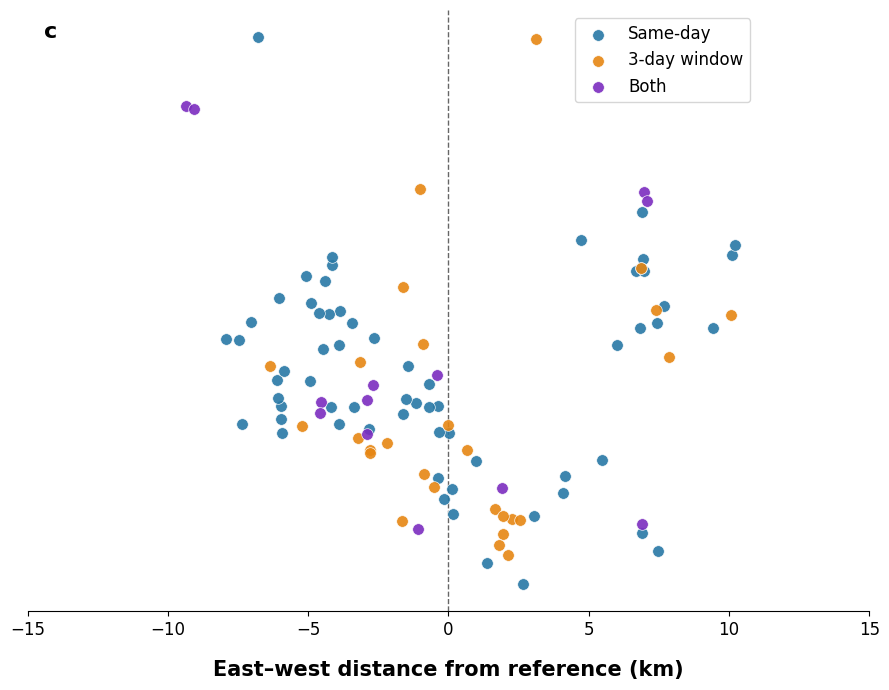

In [51]:
all_event_site_risk = plot_site_risk_distances(
    sites_gdf,
    figsize=(9, 7),
    event_filter=None,
    panel_by_event=False,
    show_cross_event=False,
    use_union_centroid=True,
    x_rotation=0,
    xlim=(-15, 15),
    diagnostics=False, 
    
    # Risk colors
    one_day_color='#2878A5',
    three_day_color='#E68613',
    both_color='#7B2CBF',
    cross_event_color='#7F7F7F',

    # Legend labels
    one_day_label='Same-day',
    three_day_label='3-day window',
    both_label='Both',
    cross_event_label='1- and 3-day risk, different events',

    # Panel labels
    panel_labels='c',
    panel_label_x=0.02,
    panel_label_y=0.98,
    panel_label_fontsize=16,
    panel_label_fontweight='bold',
    panel_label_ha='left',
    panel_label_va='top',

    # Legend
    legend_loc='upper left',
    legend_bbox=(0.64, 1.0),
    legend_fontsize=12,
    legend_title=None,
    legend_title_fontsize=12,
    legend_frame=True,  

    # Save
    # save_path=PLOTS_DIR / 'all_event_site_1_3_day_outage_odds.png',
    dpi=300
)

### EAs with increased outage odds during E.W 

In [93]:
# district_gdf.plot()

# filt_all_eas_dem_df_filt.plot()

In [82]:
eas_to_plot = filt_all_eas_dem_df_filt[['ea_code9ch', 'DIST_NAME', 'geometry', 'Pcode']].merge(eas_n_cesi_level, on = 'ea_code9ch', how = 'right').drop_duplicates(subset=['ea_code9ch']).reset_index(drop=True)

In [83]:
eas_to_plot

,ea_code9ch,DIST_NAME,geometry,Pcode,cesi_level
0,30200002,GA WEST,"POLYGON ((799017.814 623458.371, 799051.565 62...",03,Low
1,30200012,GA WEST,"POLYGON ((799328.799 623914.862, 799292 623916...",03,Low
2,30200013,GA WEST,"POLYGON ((799909.133 624452.948, 799919.44 624...",03,Low
3,30200014,GA WEST,"POLYGON ((800503.736 624455.809, 800569.516 62...",03,Low
4,30200015,GA WEST,"POLYGON ((799640.296 624891.197, 799654.316 62...",03,Low
...,...,...,...,...,...
209,31300291,LA NKWANANANG MADINA,"POLYGON ((813765.805 629305.242, 813853.337 62...",03,High
210,31300310,LA NKWANANANG MADINA,"POLYGON ((811832.487 629333.217, 811643.775 62...",03,Low
211,31300328,LA NKWANANANG MADINA,"POLYGON ((813036.279 631092.941, 813016.813 63...",03,Low
212,31300407,LA NKWANANANG MADINA,"POLYGON ((811220.071 632428, 811219.23 632385....",03,Low


In [89]:
increased_outage_odds_low_CESI = [30200067,
 30200109,
 30200134,
 30200153,
 30200198,
 30200207,
 30200266,
 30200273,
 30200275,
 30200283,
 30200292,
 30200295,
 30200299,
 30200397,
 30300002,
 30300068,
 30300069,
 30300123,
 30300396,
 30403015,
 30404053,
 30406001,
 30406057,
 30406139,
 30408058,
 30408062,
 30408101,
 30408124,
 30410044,
 30410046,
 30410121,
 30410197,
 30411066,
 30411069,
 30500065,
 30500074,
 30500085,
 30500167,
 30500175,
 30500185,
 31100027,
 31100210,
 31100216,
 31100223,
 31200008,
 31200045,
 31200076,
 31200113,
 31200166,
 31300178,
 31300310]

In [86]:
increased_outage_odds_high_CESI = [30200065,
 30200075,
 30200076,
 30200092,
 30200098,
 30200126,
 30402283,
 30403138,
 30407042,
 30407084,
 30410135,
 30410146,
 30410175,
 30410186,
 30410194,
 31300205,
 31300237,
 31300267]

In [90]:
# Ensure consistent EA-code types
high_cesi_eas = {str(x) for x in increased_outage_odds_high_CESI}
low_cesi_eas = {str(x) for x in increased_outage_odds_low_CESI}

base = filt_all_eas_dem_df_filt.copy()
eas_interest = eas_to_plot.copy()

base["ea_code9ch"] = base["ea_code9ch"].astype(str)
eas_interest["ea_code9ch"] = eas_interest["ea_code9ch"].astype(str)

# Separate plotting groups
high_cesi_interest = eas_interest[
    eas_interest["ea_code9ch"].isin(high_cesi_eas)
]

low_cesi_interest = eas_interest[
    eas_interest["ea_code9ch"].isin(low_cesi_eas)
]

other_interest = eas_interest[
    ~eas_interest["ea_code9ch"].isin(high_cesi_eas | low_cesi_eas)
]

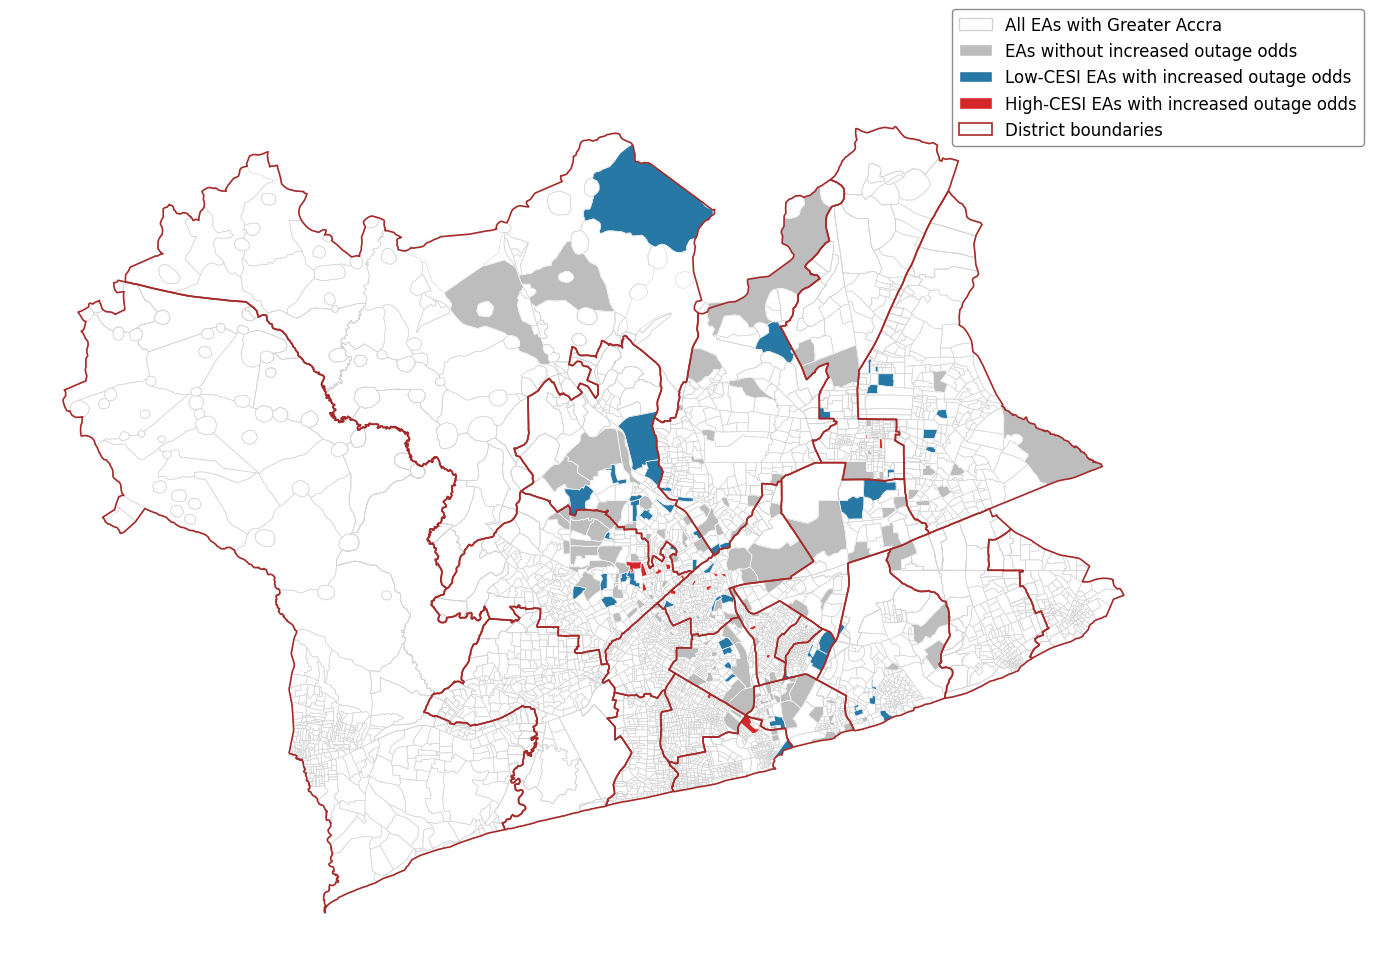

All EAs of interest: 214
Other EAs of interest: 145
Low-CESI increased-odds EAs: 51
High-CESI increased-odds EAs: 18


In [100]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(14, 12))

# All EAs
base.plot(
    ax=ax,
    facecolor="none",
    edgecolor="lightgrey",
    linewidth=0.4,
    zorder=1
)

# Other EAs of interest
other_interest.plot(
    ax=ax,
    facecolor="#BDBDBD",
    edgecolor="white",
    linewidth=0.5,
    zorder=2
)

# Low-CESI EAs with increased outage odds
low_cesi_interest.plot(
    ax=ax,
    facecolor="#2878A5",
    edgecolor="white",
    linewidth=0.5,
    zorder=3
)

# High-CESI EAs with increased outage odds
high_cesi_interest.plot(
    ax=ax,
    facecolor="#D62728",
    edgecolor="white",
    linewidth=0.5,
    zorder=3
)

# District boundaries
district_gdf.to_crs(base.crs).plot(
    ax=ax,
    facecolor="none",
    edgecolor="brown",
    linewidth=1.2,
    zorder=4
)

legend_handles = [
    Patch(
        facecolor="none",
        edgecolor="lightgrey",
        label="All EAs with Greater Accra"
    ),
    Patch(
        facecolor="#BDBDBD",
        edgecolor="white",
        label="EAs without increased outage odds"
    ),
    Patch(
        facecolor="#2878A5",
        edgecolor="white",
        label="Low-CESI EAs with increased outage odds"
    ),
    Patch(
        facecolor="#D62728",
        edgecolor="white",
        label="High-CESI EAs with increased outage odds"
    ),
    Patch(
        facecolor="none",
        edgecolor="brown",
        linewidth=1.2,
        label="District boundaries"
    )
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(0.80, 1.10),
    frameon=True,
    facecolor="white",
    edgecolor="grey",
    framealpha=0.9,
    fontsize=12
)


ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"All EAs of interest: {len(eas_interest):,}")
print(f"Other EAs of interest: {len(other_interest):,}")
print(f"Low-CESI increased-odds EAs: {len(low_cesi_interest):,}")
print(f"High-CESI increased-odds EAs: {len(high_cesi_interest):,}")

### Plot same-day elevated risk EAs --> Temp 

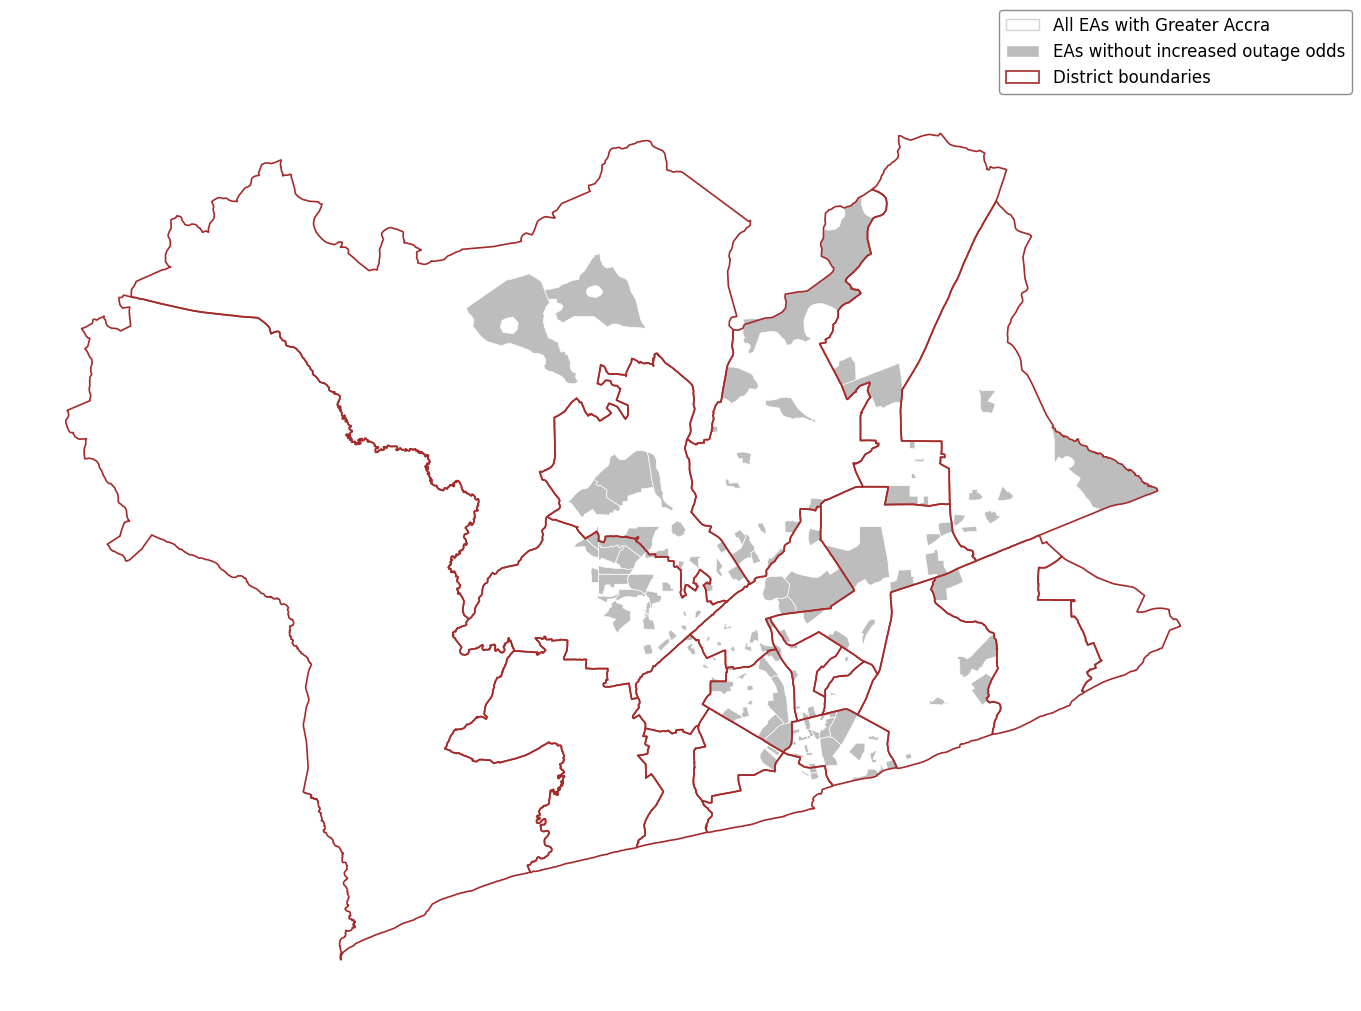

In [104]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(14, 12))

# All EAs
base.plot(
    ax=ax,
    facecolor="none",
    edgecolor="white",
    linewidth=0.4,
    zorder=1
)

# Other EAs of interest
other_interest.plot(
    ax=ax,
    facecolor="#BDBDBD",
    edgecolor="white",
    linewidth=0.5,
    zorder=2
)

# # Low-CESI EAs with increased outage odds
# low_cesi_interest.plot(
#     ax=ax,
#     facecolor="#2878A5",
#     edgecolor="white",
#     linewidth=0.5,
#     zorder=3
# )

# # High-CESI EAs with increased outage odds
# high_cesi_interest.plot(
#     ax=ax,
#     facecolor="#D62728",
#     edgecolor="white",
#     linewidth=0.5,
#     zorder=3
# )

# District boundaries
district_gdf.to_crs(base.crs).plot(
    ax=ax,
    facecolor="none",
    edgecolor="brown",
    linewidth=1.2,
    zorder=4
)

legend_handles = [
    Patch(
        facecolor="none",
        edgecolor="lightgrey",
        label="All EAs with Greater Accra"
    ),
    Patch(
        facecolor="#BDBDBD",
        edgecolor="white",
        label="EAs"
    ),
    Patch(
        facecolor="none",
        edgecolor="brown",
        linewidth=1.2,
        label="District boundaries"
    )
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(0.80, 1.10),
    frameon=True,
    facecolor="white",
    edgecolor="grey",
    framealpha=0.9,
    fontsize=12
)


ax.set_axis_off()
plt.tight_layout()
plt.show()

### Read the same-day source file

In [150]:
same_day_summary_df = pd.read_csv(DATA_DIR / 'miscellaneous/summary_df_same_day_rev1.csv').drop(columns = ['Unnamed: 0'])

In [151]:
same_day_summary_df['ea_code9ch'] = same_day_summary_df['ea_code9ch'].astype('int64')
eas_n_cesi_level['ea_code9ch'] = eas_n_cesi_level['ea_code9ch'].astype('int64')

same_day_summary_df = same_day_summary_df.merge(
    eas_n_cesi_level,
    on='ea_code9ch'
)

In [152]:
same_day_summary_df

,ea_code9ch,event,odds_ratio,cesi_level
0,30200065,T,3.96,High
1,30200067,T,3.31,Low
2,30200075,T,2.21,High
3,30200076,T,4.23,High
4,30200092,T,3.09,High
...,...,...,...,...
69,31300178,P,3.15,Low
70,31300205,L,9.31,High
71,31300237,L,6.00,High
72,31300267,P,3.36,High


In [157]:
common_x_ref_offset = 4     # km east if use_km=True
common_y_ref_offset = -1 

fig_size=(10, 8)

common_xlim = (-18, 18)
common_ylim = (-12, 22)

### Visualize -- plot the centroids 

In [164]:
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from shapely import affinity


def plot_same_day_outage_risk_relative(
    base_gdf,
    summary_df,
    event="T",
    ea_col="ea_code9ch",
    event_col="event",
    cesi_col="cesi_level",

    # CESI colors and labels
    cesi_colors=None,
    cesi_order=("Low", "High"),
    cesi_legend_labels=None,

    # Reference point
    use_union_centroid=True,
    ref_easting=None,
    ref_northing=None,
    x_ref_offset=0,
    y_ref_offset=0,
    use_km=True,

    # Background EA map
    show_basemap=False,
    basemap_facecolor="none",
    basemap_edgecolor="lightgrey",
    basemap_linewidth=0.4,
    basemap_alpha=1.0,

    # Centroid styling
    point_size=80,
    point_edgecolor="white",
    point_linewidth=0.8,
    point_marker="o",
    point_alpha=1.0,

    # Reference lines
    show_reference_lines=True,
    reference_linecolor="black",
    reference_linestyle="--",
    reference_linewidth=1,
    reference_alpha=0.5,

    # Reference point marker
    show_reference_point=False,
    reference_point_size=80,
    reference_point_marker="X",
    reference_point_color="black",

    # Figure and axes
    figsize=(10, 8),
    xlim=None,
    ylim=None,
    show_yaxis=True,

    # Axis labels
    x_label=None,
    y_label=None,
    axis_label_fontsize=15,
    axis_label_fontweight="bold",
    axis_labelpad=12,

    # Tick labels
    x_tick_fontsize=12,
    y_tick_fontsize=12,
    x_rotation=0,

    # Same colors as histogram
    cesi_colors={
        "Low": "tab:blue",
        "High": "tab:orange"
    },
    cesi_order=("Low", "High"),
    cesi_legend_labels={
        "Low": "Low CESI",
        "High": "High CESI"
    },

    # Panel label using ax.transAxes
    panel_label=None,
    panel_label_x=0.02,
    panel_label_y=0.98,
    panel_label_fontsize=16,
    panel_label_fontweight="bold",
    panel_label_ha="left",
    panel_label_va="top",

    # Legend
    show_legend=True,
    legend_title=None,
    legend_title_fontsize=12,
    legend_loc="upper left",
    legend_bbox=(0.60, 1.10),
    legend_fontsize=12,
    legend_marker_size=10,
    legend_frame=True,
    legend_facecolor="white",
    legend_edgecolor="grey",
    legend_framealpha=0.9,

    # Optional title
    title=None,
    title_fontsize=16,
    title_fontweight="bold",
    title_pad=15,

    # Output
    print_count=True,
    save_path=None,
    dpi=300
):
    """
    Plot centroids of EAs with increased same-day outage risk for a
    selected weather event.

    Locations are expressed as east-west and north-south distances
    from a common reference point. Centroid colors indicate CESI level.

    Duplicate EA polygon rows in base_gdf are dissolved so that each
    EA has one geometry and one centroid.
    """

    # -------------------------------------------------
    # Default CESI styling
    # -------------------------------------------------
    if cesi_colors is None:
        cesi_colors = {
            "Low": "#2878A5",
            "High": "#D62728"
        }

    if cesi_legend_labels is None:
        cesi_legend_labels = {
            "Low": "Low CESI",
            "High": "High CESI"
        }

    # -------------------------------------------------
    # Prepare input data
    # -------------------------------------------------
    base = gpd.GeoDataFrame(
        base_gdf.copy(),
        geometry="geometry",
        crs=base_gdf.crs
    )

    results = summary_df.copy()

    # Check CRS
    if base.crs is None:
        raise ValueError(
            "base_gdf must have a defined CRS."
        )

    if base.crs.is_geographic:
        raise ValueError(
            "base_gdf must use a projected CRS before calculating "
            "centroids and distances. For Greater Accra, you can use "
            "base_gdf.to_crs(epsg=32630)."
        )

    # Check required base columns
    required_base_columns = {
        ea_col,
        "geometry"
    }

    missing_base_columns = (
        required_base_columns - set(base.columns)
    )

    if missing_base_columns:
        raise ValueError(
            f"Missing columns in base_gdf: "
            f"{sorted(missing_base_columns)}"
        )

    # Check required results columns
    required_result_columns = {
        ea_col,
        event_col,
        cesi_col
    }

    missing_result_columns = (
        required_result_columns - set(results.columns)
    )

    if missing_result_columns:
        raise ValueError(
            f"Missing columns in summary_df: "
            f"{sorted(missing_result_columns)}"
        )

    # -------------------------------------------------
    # Clean and dissolve base geometries
    # -------------------------------------------------
    base = base.dropna(
        subset=[ea_col, "geometry"]
    ).copy()

    base = base[
        ~base.geometry.is_empty
    ].copy()

    # Standardize EA codes
    base[ea_col] = (
        base[ea_col]
        .astype(str)
        .str.strip()
    )

    # Combine duplicate polygon rows into one geometry per EA
    base = (
        base[[ea_col, "geometry"]]
        .dissolve(
            by=ea_col,
            as_index=False
        )
    )

    if not base[ea_col].is_unique:
        raise ValueError(
            "EA codes are still duplicated after dissolving."
        )

    # -------------------------------------------------
    # Clean results
    # -------------------------------------------------
    results = results.dropna(
        subset=[ea_col, event_col, cesi_col]
    ).copy()

    results[ea_col] = (
        results[ea_col]
        .astype(str)
        .str.strip()
    )

    results[event_col] = (
        results[event_col]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    results[cesi_col] = (
        results[cesi_col]
        .astype(str)
        .str.strip()
        .str.title()
    )

    event = str(event).strip().upper()

    available_events = sorted(
        results[event_col].unique()
    )

    if event not in available_events:
        raise ValueError(
            f"Event '{event}' was not found. "
            f"Available events are: {available_events}"
        )

    # -------------------------------------------------
    # Select results for requested event
    # -------------------------------------------------
    event_results = results.loc[
        results[event_col].eq(event),
        [ea_col, cesi_col]
    ].copy()

    # Check whether an EA has conflicting CESI categories
    cesi_counts_per_ea = (
        event_results
        .groupby(ea_col)[cesi_col]
        .nunique()
    )

    conflicting_eas = (
        cesi_counts_per_ea[
            cesi_counts_per_ea > 1
        ]
        .index
        .tolist()
    )

    if conflicting_eas:
        raise ValueError(
            "Some EAs have more than one CESI category: "
            f"{conflicting_eas[:10]}"
        )

    # Keep one result row per EA
    event_results = (
        event_results
        .drop_duplicates(subset=[ea_col])
        .reset_index(drop=True)
    )

    # -------------------------------------------------
    # Join CESI categories to EA geometries
    # -------------------------------------------------
    event_interest = base.merge(
        event_results,
        on=ea_col,
        how="inner",
        validate="one_to_one"
    )

    event_interest = gpd.GeoDataFrame(
        event_interest,
        geometry="geometry",
        crs=base.crs
    )

    if event_interest.empty:
        raise ValueError(
            f"No matching EA geometries were found for event "
            f"'{event}'."
        )

    # -------------------------------------------------
    # Calculate EA centroids
    # -------------------------------------------------
    event_centroids = event_interest.copy()

    event_centroids["geometry"] = (
        event_interest.geometry.centroid
    )

    event_centroids["easting"] = (
        event_centroids.geometry.x
    )

    event_centroids["northing"] = (
        event_centroids.geometry.y
    )

    # -------------------------------------------------
    # Define common reference point
    # -------------------------------------------------
    if use_union_centroid:
        try:
            base_union = base.geometry.union_all()
        except Exception:
            base_union = base.geometry.unary_union

        reference_point = base_union.centroid

        ref_easting = reference_point.x
        ref_northing = reference_point.y

    else:
        if ref_easting is None or ref_northing is None:
            raise ValueError(
                "Provide both ref_easting and ref_northing when "
                "use_union_centroid=False."
            )

    # -------------------------------------------------
    # Apply reference offsets
    # -------------------------------------------------
    if use_km:
        ref_easting += x_ref_offset * 1000
        ref_northing += y_ref_offset * 1000

        conversion_factor = 1000
        unit_label = "km"

    else:
        ref_easting += x_ref_offset
        ref_northing += y_ref_offset

        conversion_factor = 1
        unit_label = "m"

    # -------------------------------------------------
    # Calculate coordinates relative to reference
    # -------------------------------------------------
    event_centroids["x_distance"] = (
        event_centroids["easting"] - ref_easting
    ) / conversion_factor

    event_centroids["y_distance"] = (
        event_centroids["northing"] - ref_northing
    ) / conversion_factor

    # -------------------------------------------------
    # Diagnostics
    # -------------------------------------------------
    if print_count:
        print(
            f"{event} EA centroids plotted: "
            f"{event_centroids[ea_col].nunique()}"
        )

        print("\nCESI counts:")

        print(
            event_centroids[cesi_col]
            .value_counts()
            .reindex(
                cesi_order,
                fill_value=0
            )
        )

        print(
            f"\nReference offset: "
            f"x={x_ref_offset} {unit_label}, "
            f"y={y_ref_offset} {unit_label}"
        )

    # -------------------------------------------------
    # Create figure
    # -------------------------------------------------
    fig, ax = plt.subplots(
        figsize=figsize
    )

    # -------------------------------------------------
    # Optional relative-coordinate EA basemap
    # -------------------------------------------------
    if show_basemap:
        relative_base = base.copy()

        relative_base["geometry"] = (
            relative_base.geometry.apply(
                lambda geom: affinity.scale(
                    affinity.translate(
                        geom,
                        xoff=-ref_easting,
                        yoff=-ref_northing
                    ),
                    xfact=1 / conversion_factor,
                    yfact=1 / conversion_factor,
                    origin=(0, 0)
                )
            )
        )

        relative_base.plot(
            ax=ax,
            facecolor=basemap_facecolor,
            edgecolor=basemap_edgecolor,
            linewidth=basemap_linewidth,
            alpha=basemap_alpha,
            zorder=1
        )

    # -------------------------------------------------
    # Plot EA centroids by CESI category
    # -------------------------------------------------
    observed_levels = list(
        event_centroids[cesi_col]
        .dropna()
        .unique()
    )

    ordered_observed_levels = [
        level
        for level in cesi_order
        if level in observed_levels
    ]

    unexpected_levels = [
        level
        for level in observed_levels
        if level not in cesi_order
    ]

    plot_levels = (
        ordered_observed_levels
        + unexpected_levels
    )

    for cesi_level in plot_levels:
        cesi_subset = event_centroids[
            event_centroids[cesi_col].eq(
                cesi_level
            )
        ]

        ax.scatter(
            cesi_subset["x_distance"],
            cesi_subset["y_distance"],
            s=point_size,
            c=cesi_colors.get(
                cesi_level,
                "#7F7F7F"
            ),
            marker=point_marker,
            edgecolors=point_edgecolor,
            linewidths=point_linewidth,
            alpha=point_alpha,
            zorder=3
        )

    # -------------------------------------------------
    # Reference lines
    # -------------------------------------------------
    if show_reference_lines:
        ax.axhline(
            0,
            color=reference_linecolor,
            linestyle=reference_linestyle,
            linewidth=reference_linewidth,
            alpha=reference_alpha,
            zorder=2
        )

        ax.axvline(
            0,
            color=reference_linecolor,
            linestyle=reference_linestyle,
            linewidth=reference_linewidth,
            alpha=reference_alpha,
            zorder=2
        )

    # -------------------------------------------------
    # Reference point
    # -------------------------------------------------
    if show_reference_point:
        ax.scatter(
            0,
            0,
            s=reference_point_size,
            c=reference_point_color,
            marker=reference_point_marker,
            zorder=4
        )

    # -------------------------------------------------
    # Panel label using ax.transAxes
    # -------------------------------------------------
    if panel_label is not None:
        ax.text(
            panel_label_x,
            panel_label_y,
            str(panel_label),
            transform=ax.transAxes,
            fontsize=panel_label_fontsize,
            fontweight=panel_label_fontweight,
            horizontalalignment=panel_label_ha,
            verticalalignment=panel_label_va,
            clip_on=False,
            zorder=10
        )

    # -------------------------------------------------
    # Axis labels
    # -------------------------------------------------
    if x_label is None:
        x_label = (
            f"East–west distance from reference "
            f"({unit_label})"
        )

    if y_label is None:
        y_label = (
            f"North–south distance from reference "
            f"({unit_label})"
        )

    ax.set_xlabel(
        x_label,
        fontsize=axis_label_fontsize,
        fontweight=axis_label_fontweight,
        labelpad=axis_labelpad
    )

    ax.set_ylabel(
        y_label,
        fontsize=axis_label_fontsize,
        fontweight=axis_label_fontweight,
        labelpad=axis_labelpad
    )

    # -------------------------------------------------
    # Axis ticks
    # -------------------------------------------------
    ax.tick_params(
        axis="x",
        labelsize=x_tick_fontsize,
        labelrotation=x_rotation
    )

    ax.tick_params(
        axis="y",
        labelsize=y_tick_fontsize
    )

    # Hide y-axis if requested
    if not show_yaxis:
        ax.yaxis.set_visible(False)
        ax.spines["left"].set_visible(False)

    # Axis limits
    if xlim is not None:
        ax.set_xlim(xlim)

    if ylim is not None:
        ax.set_ylim(ylim)

    # Preserve spatial proportions
    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # -------------------------------------------------
    # CESI-only legend
    # -------------------------------------------------
    if show_legend:
        legend_handles = [
            Line2D(
                [0],
                [0],
                marker=point_marker,
                linestyle="none",
                markerfacecolor=cesi_colors.get(
                    level,
                    "#7F7F7F"
                ),
                markeredgecolor=point_edgecolor,
                markeredgewidth=point_linewidth,
                markersize=legend_marker_size,
                label=cesi_legend_labels.get(
                    level,
                    level
                )
            )
            for level in plot_levels
        ]

        ax.legend(
            handles=legend_handles,
            title=legend_title,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox,
            frameon=legend_frame,
            facecolor=legend_facecolor,
            edgecolor=legend_edgecolor,
            framealpha=legend_framealpha,
            fontsize=legend_fontsize,
            title_fontsize=legend_title_fontsize
        )

    # -------------------------------------------------
    # Optional title
    # -------------------------------------------------
    if title is not None:
        ax.set_title(
            title,
            fontsize=title_fontsize,
            fontweight=title_fontweight,
            pad=title_pad
        )

    plt.tight_layout()

    # -------------------------------------------------
    # Optional save
    # -------------------------------------------------
    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()

    return fig, ax, event_centroids

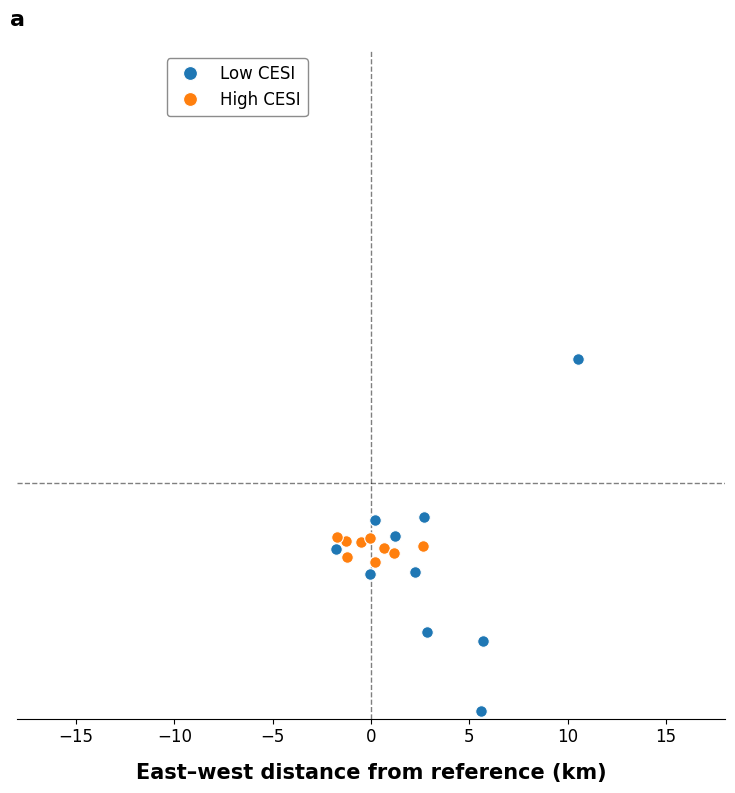

In [176]:
fig, ax, precipitation_centroids = (
    plot_same_day_outage_risk_relative(
        base_gdf=filt_all_eas_dem_df_filt,
        summary_df=same_day_summary_df,
        event="T",
        print_count=False, 

        use_union_centroid=True,
        use_km=True,
        x_ref_offset=common_x_ref_offset,
        y_ref_offset=common_y_ref_offset,

        show_yaxis=False,
        show_basemap=False,

        # CESI styling
        cesi_colors={
            "Low": "tab:blue",
            "High": "tab:orange"
        },
        cesi_order=("Low", "High"),
        cesi_legend_labels={
            "Low": "Low CESI",
            "High": "High CESI"
        },

        point_size=70,
        point_edgecolor="white",
        point_linewidth=0.8,

        # Panel label
        panel_label="a",
        panel_label_x=-0.01,
        panel_label_y=1.06,
        panel_label_fontsize=16,

        # Legend
        legend_title=None,
        legend_loc="upper left",
        legend_bbox=(0.20, 1.00),
        legend_fontsize=12,

        figsize=fig_size,
        xlim=common_xlim,
        ylim=common_ylim, 

        # Save figure
        # save_path=PLOTS_DIR / "elevated_risk_by_CESI_Temp.png",
        dpi=300
    )
)